# Linear Regression From Scratch

## 01. Data Exploration

In this notebook, we will explore the house price dataset before building
Linear Regression models from scratch.

### Objectives
- Understand the dataset
- Identify features and target
- Check missing values
- Understand data types
- Explore basic statistics
- Visualize relationships between features and house price

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [91]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [92]:
df.shape

(20640, 9)

In [93]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [95]:
X = df.iloc[:,0:8]
y = df.iloc[:,-1]

In [96]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [97]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [98]:
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [99]:
y.isnull().sum()

np.int64(0)

In [100]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [101]:
X.corrwith(y)

MedInc        0.688075
HouseAge      0.105623
AveRooms      0.151948
AveBedrms    -0.046701
Population   -0.024650
AveOccup     -0.023737
Latitude     -0.144160
Longitude    -0.045967
dtype: float64

Text(0.5, 1.0, 'Median Income vs House Value')

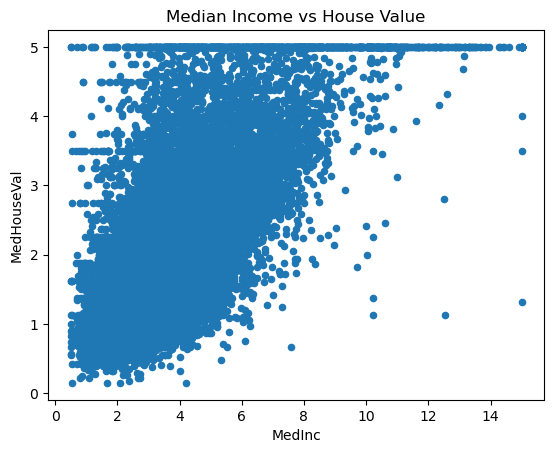

In [102]:
df.plot(x='MedInc', y='MedHouseVal', kind='scatter')
plt.title('Median Income vs House Value')

### Observations

1. The relationship between `MedInc` and `MedHouseVal` appears to be generally positive, but it is not perfectly linear.

2. Most observations show that higher median income is associated with higher median house value.

3. There are some observations where relatively lower-income areas have comparatively high house values. These points may be unusual observations, but they should not be considered outliers without further analysis.

4. The target variable appears to have a noticeable upper limit around `5`, which may affect the relationship and the performance of a Linear Regression model.

In [103]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [104]:
print(y.max())
print(y.min())

5.00001
0.14999


<Axes: >

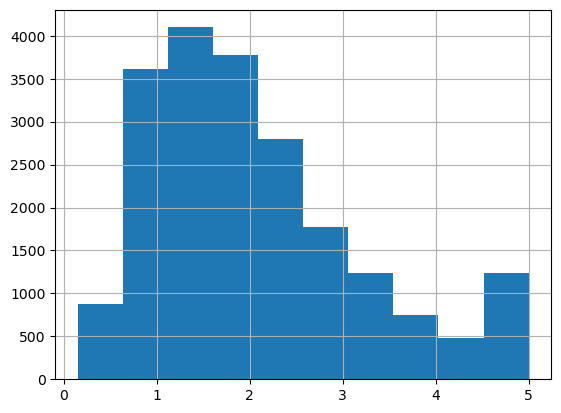

In [105]:
y.hist()

<Axes: xlabel='MedHouseVal', ylabel='Density'>

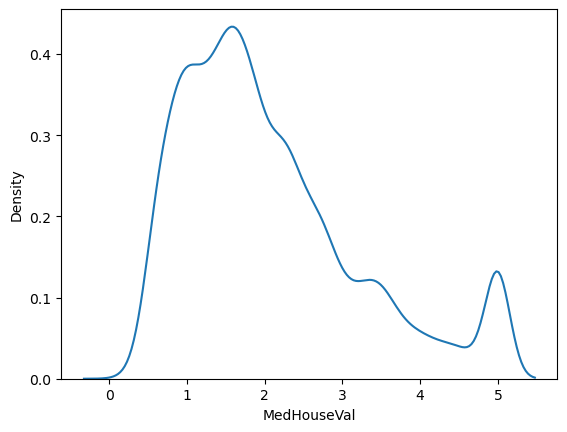

In [106]:
import seaborn as sns
sns.kdeplot(y)

### Observation

1. Most of the `MedHouseVal` values are concentrated between approximately 1 and 2.

2. The distribution is right-skewed, with a long tail extending toward higher house values.

3. There is a noticeable small peak around 5, which is likely related to the upper limit of the target variable.

In [107]:
df['MedHouseVal'].nunique()

3842

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
X.mean()

MedInc           3.870671
HouseAge        28.639486
AveRooms         5.429000
AveBedrms        1.096675
Population    1425.476744
AveOccup         3.070655
Latitude        35.631861
Longitude     -119.569704
dtype: float64

In [110]:
y.mean()

np.float64(2.0685581690891475)

### Why Feature Scaling Matters for Gradient Descent

Gradient Descent is an optimization technique used to minimize the cost function. 
When features have very different scales, the cost surface can become elongated, 
which can cause Gradient Descent to move in a zig-zag direction and converge slowly.
Feature scaling helps Gradient Descent move toward the minimum more efficiently.

In [111]:
print(X.min())
print(X.max())

MedInc          0.499900
HouseAge        1.000000
AveRooms        0.846154
AveBedrms       0.333333
Population      3.000000
AveOccup        0.692308
Latitude       32.540000
Longitude    -124.350000
dtype: float64
MedInc           15.000100
HouseAge         52.000000
AveRooms        141.909091
AveBedrms        34.066667
Population    35682.000000
AveOccup       1243.333333
Latitude         41.950000
Longitude      -114.310000
dtype: float64


In [112]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [113]:
X_scaled.shape

(20640, 8)

In [114]:
X_scaled.mean()

np.float64(-7.864510076763318e-16)

In [115]:
X_scaled.std()

np.float64(1.0)

<Axes: ylabel='Density'>

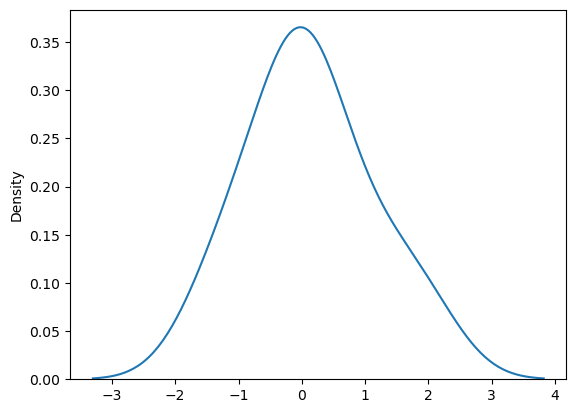

In [116]:
sns.kdeplot(X_scaled[4])

We standardize X because Gradient Descent uses the feature values to update the model parameters. We usually keep y in its original scale because y is the target value we ultimately want to predict.

When features have different scales, Gradient Descent can take a zig-zag path and converge slowly. Standardization puts the features on a comparable scale, allowing Gradient Descent to converge more efficiently.

In [117]:
print(f"Before scaling mean: {X['MedInc'].mean()}")
print(f"After scaling mean: {X_scaled[:, 0].mean()}")

print(f"Before scaling std: {X['MedInc'].std()}")
print(f"After scaling std: {X_scaled[:, 0].std()}")

Before scaling mean: 3.8706710029069766
After scaling mean: 5.508083222946513e-17
Before scaling std: 1.8998217179452732
After scaling std: 0.9999999999999999


In [118]:
X_scaled.mean()

np.float64(-7.864510076763318e-16)

In [119]:
X_scaled.mean(axis=0) # axis = 0 = columns

array([ 5.50808322e-17,  4.40646658e-17,  7.71131651e-17, -1.00522519e-16,
       -1.10161664e-17,  0.00000000e+00,  2.24729795e-15, -8.60362599e-15])

In [120]:
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=4)

In [123]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16512, 8)
(4128, 8)


In [126]:
print(y_train.shape)
print(y_test.shape)

(16512,)
(4128,)


## Final Summary

- The California Housing dataset contains 20,640 rows and 8 input features.
- `MedHouseVal` is the target variable that we want to predict.
- The dataset does not contain any missing values or duplicate rows.
- Feature scaling is important because the features have very different numerical ranges. We used Standardization to make the feature mean approximately 0 and standard deviation approximately 1.
- The data was split into 80% training data and 20% testing data. The scaler was fitted only on the training data to avoid data leakage.